In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN
from kmedoids import KMedoids
from sklearn.metrics import adjusted_rand_score

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster, benchmark_functional_groups

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["onehot"])
df = qm9.load()
molecules = qm9.get_molecules()
X = np.array(df['selfies_onehot'].to_list())

2026-04-23 08:43:46.542 | INFO     | src.datasets:load:584 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-04-23 08:43:46.844 | INFO     | src.datasets:_sample_qm9_df:776 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-04-23 08:43:46.845 | INFO     | src.datasets:_add_requested_descriptors:195 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-04-23 08:43:46.845 | INFO     | src.features:compute_selfies_onehot:142 - Computing One-Hot Encodings...
2026-04-23 08:43:48.037 | INFO     | src.datasets:_add_requested_descriptors:218 - Added descriptor column(s): ['selfies_onehot']
2026-04-23 08:44:16.586 | SUCCESS  | src.datasets:get_molecules:1274 - Saved 5000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 5000).


In [5]:
ls_selfies = np.array(df['selfies_onehot'].to_list())
ls_selfies[0]

array([0, 0, 0, ..., 0, 0, 1], shape=(2795,))

In [5]:
df

mol_id,formula,smiles,canonical_smiles,scaffold_smiles,generic_scaffold,root_scaffold,brics_fragments,scaffold_tree_nodes,selfies,functional_groups,structure_class,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,selfies_onehot
str,str,str,str,str,str,str,str,str,str,str,str,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i64]
"""qm9_21""","""C3H8O""","""[H]OC([H])(C([H])([H])[H])C([H…","""[H]OC([H])(C([H])([H])[H])C([H…","""Acyclic""","""Acyclic""","""Acyclic""","""[3*]O[H],[4*]C([H])(C([H])([H]…","""""","""[H][O][C][Branch1][C][H][Branc…","""alcohol""","""Acyclic""",60,0,20,0.940086,13.015533,4,0,0,0,1,12,1.833333,3,0.0,0.0,1.0,1,1,3,0,0,3,4,24,1.199232,0,1,0,0,0,0,0,0,0,0,1.4259,38.580002,-7.107614,2.013643,9.118535,318.372101,2.929931,-5286.280273,-5286.131348,-5286.105469,-5287.026855,19.052,-45.175072,-45.4883,-45.77108,-42.007965,8.67553,8.00568,4.75542,"[0, 0, … 1]"
"""qm9_34""","""C3H6O""","""[H]C(=O)C([H])([H])C([H])([H])…","""[H]C(=O)C([H])([H])C([H])([H])…","""Acyclic""","""Acyclic""","""Acyclic""","""[H]C(=O)C([H])([H])C([H])([H])…","""""","""[H][C][=Branch1][C][=O][C][Bra…","""""","""Acyclic""",58,0,17,0.977264,12.898953,4,0,0,0,1,10,1.8,2,0.0,0.333333,0.666667,0,1,3,0,1,2,4,20,1.213143,0,0,0,0,0,0,0,0,0,0,2.6741,35.830002,-6.802846,-0.557833,6.245013,333.327606,2.290518,-5253.84375,-5253.705566,-5253.679688,-5254.594727,15.954,-39.964523,-40.211521,-40.442844,-37.381725,26.145639,4.2893,4.12773,"[0, 0, … 1]"
"""qm9_89""","""C3H5NO""","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H]N1C([H])([H])C(=O)C1([H])[H…","""O=C1CNC1""","""CC1CCC1""","""*=*1***1""","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H][N][C][Branch1][C][H][Branc…","""ketone""","""Aliphatic Ring""",71,0,29,0.761845,12.992522,5,1,0,0,2,10,2.0,0,0.0,0.333333,0.666667,1,2,4,0,1,2,4,20,1.261328,0,0,0,0,0,0,0,1,0,0,2.5257,39.34,-6.631414,-0.702054,5.929361,359.152008,2.167387,-6726.387695,-6726.26123,-6726.235352,-6727.135742,16.083,-40.819069,-41.077904,-41.309227,-38.114258,11.54185,4.90368,3.63309,"[0, 0, … 1]"
"""qm9_92""","""C4H8O""","""[H]C1([H])O[C@@]([H])(C([H])([…","""[H]C1([H])O[C@@]([H])(C([H])([…","""C1COC1""","""C1CCC1""","""*1***1""","""[8*]C([H])([H])[H],[13*][C@]1(…","""[H]C1([H])O[C@@]([H])(C([H])([…","""[H][C][Branch1][C][H][O][C@@][…","""ether""","""Aliphatic Ring""",72,0,9,0.964858,12.880514,5,1,0,0,1,13,2.0,1,0.0,0.0,1.0,0,1,4,0,0,4,5,27,1.243901,0,0,0,0,0,0,0,0,1,0,1.6826,45.720001,-6.557944,2.489842,9.047786,407.690887,3.118153,-6322.054688,-6321.90918,-6321.883301,-6322.826172,18.582001,-51.086094,-51.441444,-51.749908,-47.548447,9.93129,4.56362,3.63704,"[0, 0, … 1]"
"""qm9_203""","""C4H5NO""","""[H]OC1=C([H])N([H])C([H])=C1[H…","""[H]Oc1c([H])c([H])n([H])c1[H]""","""c1cc[nH]c1""","""C1CCCC1""","""*1:*:*:*:*:1""","""[16*]c1c([H])c([H])n([H])c1[H]…","""[H]Oc1c([H])c([H])n([H])c1[H],…","""[H][O][C][C][Branch1][C][H][=C…","""phenol""","""Aromatic""",83,0,36,0.807324,12.835046,6,1,1,0,2,11,2.0,1,0.0,1.0,0.0,2,1,5,0,4,0,5,19,1.231725,0,0,1,0,0,0,0,0,0,0,1.6811,47.509998,-5.072202,1.360569,6.432771,480.40329,2.351254,-7763.85498,-7763.710449,-7763.68457,-7764.625488,19.995001,-48.423428,-48.702156,-48.959167,-45.345032,8.97547,3.51643,2.52657,"[0, 0, … 1]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…

In [6]:
len(molecules[0:2])

2

In [7]:
plot_molecules_with_py3dmol(molecules[0:4])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [8]:
dist_type = "tanimoto"
dist_matrix = qm9.get_distance_matrix(
    descriptor="onehot",
    dist_type=dist_type,
    force_calculate=True
)

2026-04-22 14:04:39.737 | INFO     | src.datasets:get_distance_matrix:1044 - Calculating distance matrix for selfies_onehot using jaccard distance.
2026-04-22 14:05:03.695 | SUCCESS  | src.distance:_compute_and_save:79 - Saved distance matrix to data/QM9/dist_selfies_onehot_jaccard.npy


# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:07<00:00,  1.35it/s]


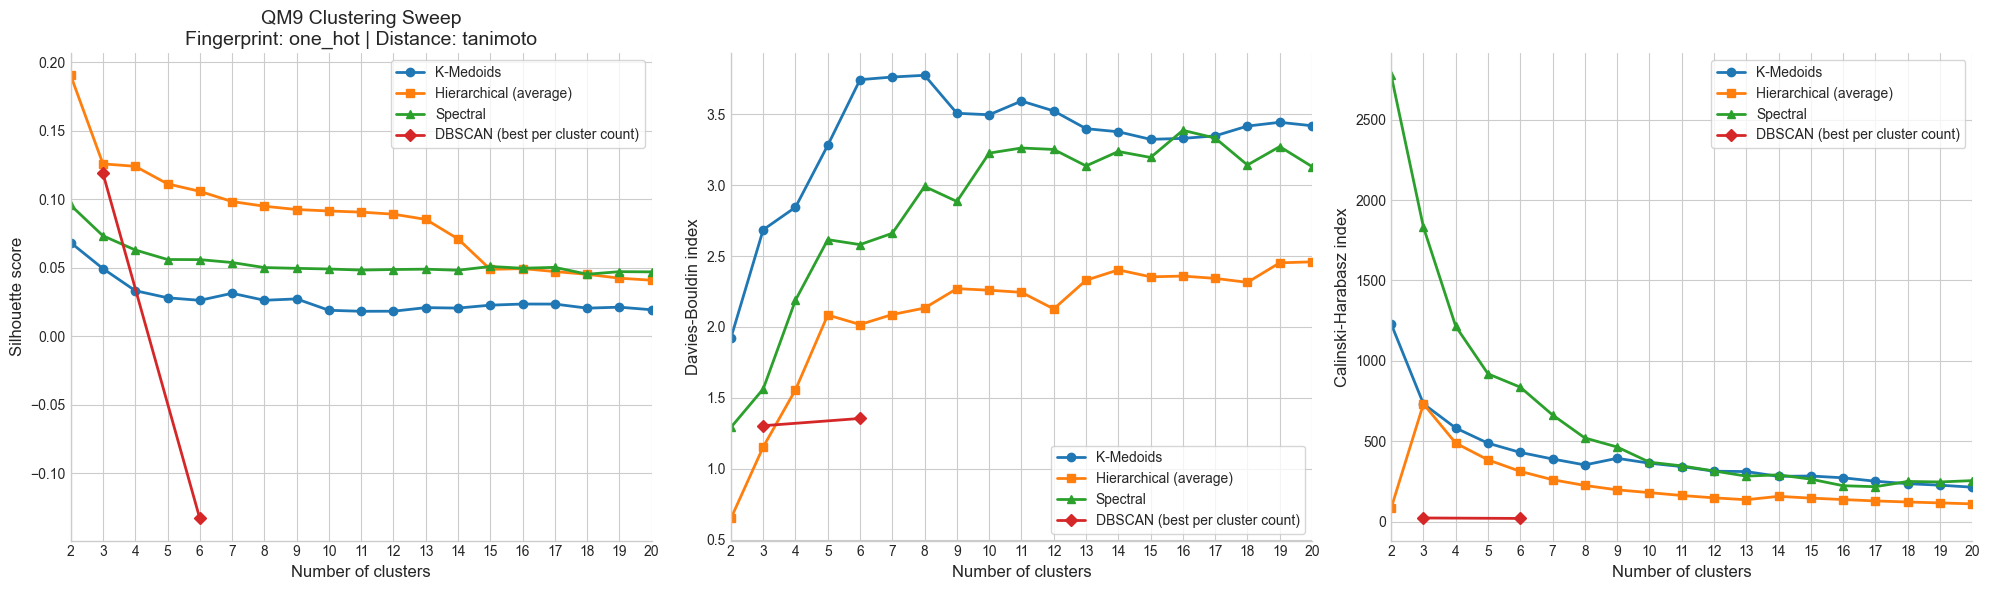

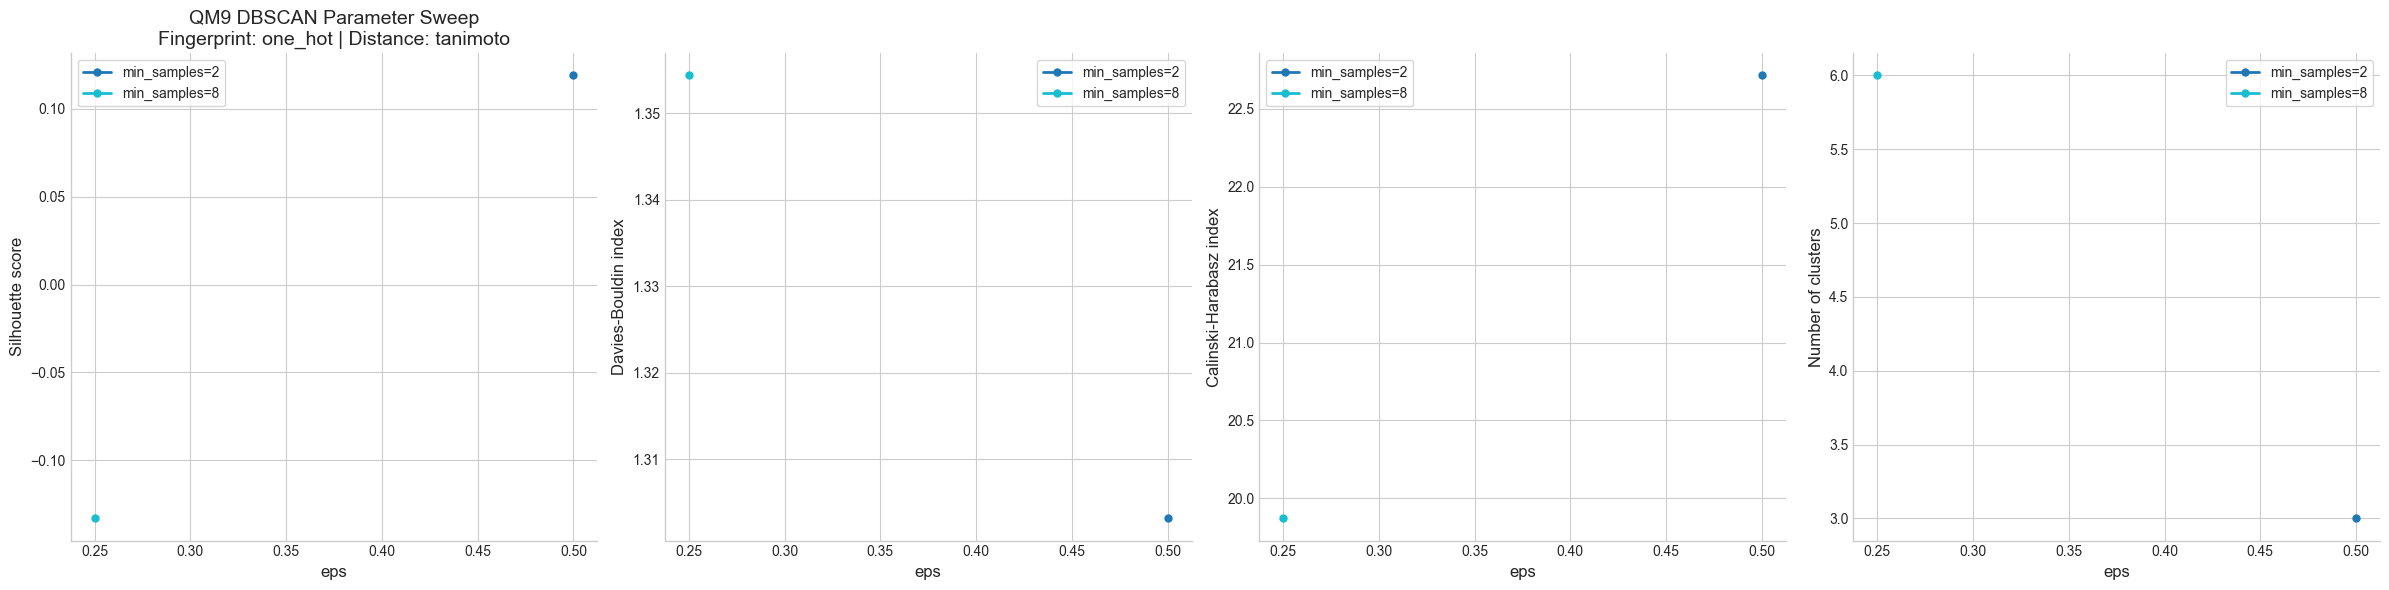

2026-04-22 14:06:02.244 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:841 - Saved clustering sweep plot to figures/qm9/clustering/tanimoto/one_hot/clustering_sweep_2_to_20_clusters.png
2026-04-22 14:06:02.244 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:843 - Saved DBSCAN evaluation plot to figures/qm9/clustering/tanimoto/one_hot/dbscan_parameter_sweep.png
2026-04-22 14:06:02.245 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:844 - Saved clustering sweep results to figures/qm9/clustering/tanimoto/one_hot/clustering_sweep_2_to_20_clusters.json


In [9]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric=dist_type,
    dataset_name="qm9",
)

In [10]:
# find the n molecules that are not on the diagonal with the smallest distance
n = 10
# Get the indices of the upper triangle (excluding diagonal)
triu_indices = np.triu_indices_from(dist_matrix, k=1)
# Get the distances and corresponding molecule pairs
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
# Get the indices of the n smallest distances
smallest_indices = np.argsort(distances)[:n]
# Get the corresponding molecule pairs for the n smallest distances
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(446), np.int64(447)), (np.int64(996), np.int64(4831)), (np.int64(2499), np.int64(2500)), (np.int64(2502), np.int64(2503)), (np.int64(4184), np.int64(4185)), (np.int64(1912), np.int64(1913)), (np.int64(3813), np.int64(3814)), (np.int64(3271), np.int64(3272)), (np.int64(4556), np.int64(4558)), (np.int64(1369), np.int64(1370))]


In [11]:
print(mols[0])

(Atoms(symbols='H8COC5HCH3', pbc=False, initial_charges=..., mass=..., partial_charge=...), Atoms(symbols='H8CHCH3OCNC3', pbc=False, initial_charges=..., mass=..., partial_charge=...))


In [12]:
plot_molecules_with_py3dmol(mols[3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Hiercical Clustering on Distance Matrix

/var/folders/_k/m1mygzyn5n7f9s1mcnb2hgxm0000gn/T/ipykernel_46386/2616862307.py:3: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  link = linkage(dist_matrix, method='average')


(array([1, 2, 3, 4, 5], dtype=int32), array([1562, 2079, 1089,    8,  262]))


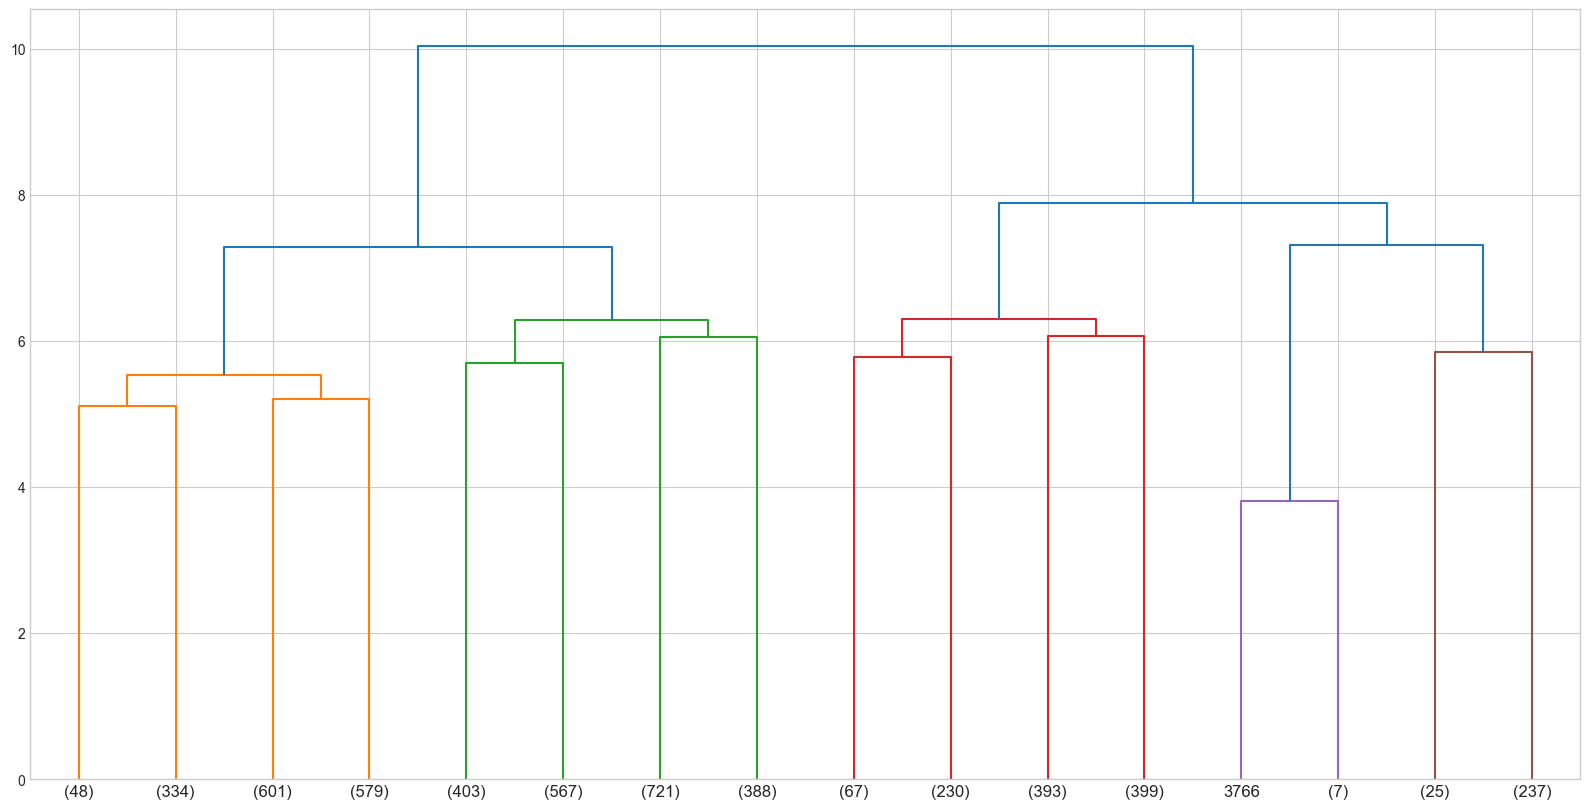

In [13]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt
link = linkage(dist_matrix, method='average')
plt.figure(figsize=(20,10))
dendrogram(link, p=3, truncate_mode='level')
labels_hier = fcluster(link, t=7, criterion='distance')
df = df.with_columns(labels_hier=labels_hier)
print(np.unique(labels_hier, return_counts=True))

In [14]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [15]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

2026-04-22 14:08:53.986 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:386 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/one_hot/pca_hierarchical_projection.png


{'coords': array([[-5.60745462,  1.4015037 ],
        [-5.61246276,  3.38903767],
        [-5.05969243,  2.23594487],
        ...,
        [-1.62225685, -1.64970579],
        [-5.76115234,  0.23034785],
        [-4.67063778, -2.31152602]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/one_hot/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/one_hot'),
 'clustering_method': 'hierarchical'}

In [16]:
d = average_numeric_by_cluster(df, "labels_hier")

shape: (5, 67)
┌─────────────┬───────┬─────────────────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬───────────┬───────────┬───────────┬───────────┬──────────┬────────┬────────┬────────────────────┬──────────────┬─────────────┬─────────────────┬──────────────────┬──────────────┬──────────────────┬──────────────────────────┬──────────────────────┬─────────────

- Clustering on unique selfies string and patterns - such as unique branching and number of atoms

In [17]:
ari_score = adjusted_rand_score(df["generic_scaffold"], df["labels_hier"])
print(f"ARI score: {ari_score} ")

ARI score: 0.014431949866576537 


In [18]:
benchmark_functional_groups(df, "labels_hier")

[{'Cluster': 1,
  'Size': 1562,
  'Top_FG_1': 'fr_ether (36.2%)',
  'Top_FG_2': 'fr_alcohol (22.8%)',
  'Top_FG_3': 'fr_amine (18.4%)'},
 {'Cluster': 2,
  'Size': 2079,
  'Top_FG_1': 'fr_ether (49.7%)',
  'Top_FG_2': 'fr_alcohol (34.4%)',
  'Top_FG_3': 'fr_ketone (14.3%)'},
 {'Cluster': 3,
  'Size': 1089,
  'Top_FG_1': 'fr_ether (46.8%)',
  'Top_FG_2': 'fr_alcohol (33.5%)',
  'Top_FG_3': 'fr_amine (9.5%)'},
 {'Cluster': 4,
  'Size': 8,
  'Top_FG_1': 'fr_benzene (0.0%)',
  'Top_FG_2': 'fr_alcohol (0.0%)',
  'Top_FG_3': 'fr_phenol (0.0%)'},
 {'Cluster': 5,
  'Size': 262,
  'Top_FG_1': 'fr_ether (42.4%)',
  'Top_FG_2': 'fr_alcohol (9.2%)',
  'Top_FG_3': 'fr_amine (4.6%)'}]

# KMedoids

In [18]:
model_km = KMedoids(n_clusters=2, metric="precomputed", random_state=42)
labels_km = model_km.fit_predict(dist_matrix)
medoid_indices = model_km.medoid_indices_
print(medoid_indices)
print(np.unique(labels_km, return_counts=True))
df = df.with_columns(labels_km=labels_km)
medoids_df = df[medoid_indices]
print(medoids_df.select(["labels_km", "mol_id", "smiles", "scaffold_smiles"]))

[ 86 111]
(array([0, 1], dtype=uint64), array([2387, 2613]))
shape: (2, 4)
┌───────────┬──────────┬─────────────────────────────────┬─────────────────┐
│ labels_km ┆ mol_id   ┆ smiles                          ┆ scaffold_smiles │
│ ---       ┆ ---      ┆ ---                             ┆ ---             │
│ u64       ┆ str      ┆ str                             ┆ str             │
╞═══════════╪══════════╪═════════════════════════════════╪═════════════════╡
│ 0         ┆ qm9_2056 ┆ [H]OC1([H])C([H])([H])C([H])([… ┆ C1CCCCC1        │
│ 1         ┆ qm9_2617 ┆ [H]C(=O)C#CC([H])([H])C([H])([… ┆ Acyclic         │
└───────────┴──────────┴─────────────────────────────────┴─────────────────┘


In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

2026-04-19 12:06:03.898 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/one_hot/pca_kmedoids_projection.png


{'coords': array([[-5.06674035,  2.43842117],
        [-4.37512824,  0.91846083],
        [-4.70031974,  2.66411482],
        ...,
        [-4.23858229, -1.21869456],
        [ 0.81222129,  0.601753  ],
        [-2.75787233, -2.06833672]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/one_hot/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/one_hot'),
 'clustering_method': 'kmedoids'}

In [19]:
average_numeric_by_cluster(df, "labels_km")

shape: (2, 68)
┌───────────┬───────┬─────────────────────┬────────────┬────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬────────────────────┬──────────────┬─────────────┬─────────────────┬──────────────────┬──────────────┬──────────────────┬───────────────────────┬──────────────────────┬─────────

labels_km,count,token_to_atom_ratio,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64
0,2387,2.138039,124.343527,0.121491,30.713029,0.896445,12.846392,8.847088,1.809384,0.035191,0.004189,2.081693,20.10641,2.07245,2.709258,0.02945,0.118127,0.852423,0.976121,1.699623,7.092166,0.206116,0.778802,5.780478,6.426477,43.084625,1.259839,0.000838,0.457478,0.005027,0.099288,0.101382,0.000838,0.027231,0.11437,0.556766,0.0,2.379518,77.98814,-6.501755,0.787324,7.289008,1232.165029,4.577966,-11056.138856,-11055.898309,-11055.872595,-11057.056817,33.257322,-81.620333,-82.139562,-82.620566,-75.861621,3.158116,1.361481,1.116047,2.600754,86.803519,3.519062,9.677419,43.084625,884,"""Acyclic""",9.677419,244,"""C1CC1""",11.101801
1,2613,1.96625,121.227325,0.025258,41.960964,0.824197,12.858486,8.717949,1.515882,0.305779,0.044776,2.792576,16.652889,2.051171,1.899349,0.102138,0.328997,0.568865,0.864524,2.310754,5.936089,0.655568,1.747799,3.522005,6.289705,33.083812,1.264916,0.004975,0.242633,0.049369,0.17145,0.125144,0.002296,0.046307,0.128971,0.499809,0.002296,2.95056,72.579089,-6.570639,-0.154319,6.416319,1152.144052,3.566294,-11280.265795,-11280.043277,-11280.017581,-11281.168181,30.147739,-70.887549,-71.298491,-71.695216,-66.068029,240.938633,1.429022,1.11754,1.577114,60.084194,29.161883,10.753923,33.083812,929,"""Acyclic""",10.753923,220,"""C1CCCC1""",18.40796


In [20]:
benchmark_functional_groups(df, "labels_km")

[{'Cluster': 0,
  'Size': 2387,
  'Top_FG_1': 'fr_ether (47.8%)',
  'Top_FG_2': 'fr_alcohol (38.8%)',
  'Top_FG_3': 'fr_ketone (11.0%)'},
 {'Cluster': 1,
  'Size': 2613,
  'Top_FG_1': 'fr_ether (41.3%)',
  'Top_FG_2': 'fr_alcohol (20.5%)',
  'Top_FG_3': 'fr_amine (15.6%)'}]

# Spectral

In [ ]:
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )

labels_spectral = model_spectral.fit_predict(dist_matrix)
df = df.with_columns(labels_spectral=labels_spectral)
print(np.unique(labels_spectral, return_counts=True))

(array([0, 1, 2], dtype=int32), array([4998,    1,    1]))


In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

2026-04-17 15:08:46.341 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/one_hot/pca_spectral_projection.png


{'coords': array([[-5.06674035,  2.43842117],
        [-4.37512824,  0.91846083],
        [-4.70031974,  2.66411482],
        ...,
        [-4.23858229, -1.21869456],
        [ 0.81222129,  0.601753  ],
        [-2.75787233, -2.06833672]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/one_hot/pca_spectral_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/one_hot'),
 'clustering_method': 'spectral'}

In [ ]:
average_numeric_by_cluster(df, "labels_spectral")

shape: (3, 61)
┌─────────────────┬───────┬─────────────────────┬───────────┬────────────┬────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬─────────────┬───────────┬────────────────────┬──────────────┬─────────────┐
│ labels_spectral ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp   ┆ tpsa    ┆ election_affinity ┆ ionization_energ

# DBSCAN 

In [ ]:
model_db = DBSCAN(
    eps=0.4,
    min_samples=4,
    metric='precomputed'
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([-1,  0,  1,  2,  3,  4,  5]), array([ 387, 4594,    4,    2,    5,    4,    4]))


In [ ]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="one_hot",
    distance_metric=dist_type,
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

2026-04-17 15:13:32.386 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:385 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/one_hot/pca_dbscan_projection.png


{'coords': array([[-5.06674035,  2.43842117],
        [-4.37512824,  0.91846083],
        [-4.70031974,  2.66411482],
        ...,
        [-4.23858229, -1.21869456],
        [ 0.81222129,  0.601753  ],
        [-2.75787233, -2.06833672]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/one_hot/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/one_hot'),
 'clustering_method': 'dbscan'}

In [ ]:
average_numeric_by_cluster(df, "labels_db")

shape: (7, 60)
┌───────────┬───────┬─────────────────────┬───────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬───────────┬───────────┬───────────┬──────────┬────────┬────────┬────────┬───────────┬────────────────────┬──────────────┬─────────────┐
│ labels_db ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp    ┆ tpsa    ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms 

# KMeans

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
labels_kmeans = kmeans.fit_predict(X)
df= df.with_columns(kmeans_labels=labels_kmeans)
print(np.unique(labels_kmeans, return_counts=True))

(array([0, 1, 2], dtype=int32), array([2095, 1530, 1375]))


In [ ]:
create_chemiscope_viewer(df, X, labels_kmeans, 'PCA')

Running PCA dimensionality reduction...
Converting structures/molecules to ASE Atoms for Chemiscope...
Assembling properties for Chemiscope...
Generating Chemiscope widget...
Saved Chemiscope input to: qm9_PCA_clustering.json
If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [ ]:
average_numeric_by_cluster(df, "kmeans_labels")

shape: (3, 59)
┌───────────────┬───────┬─────────────────────┬───────────┬────────────┬─────────┬─────────┬───────────────────┬─────────────────────┬─────────────────┬───────────┬────────────────────┬──────────────┬─────────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬───────────────────┬─────────────────┬─────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────────┬──────────┬───────────┬──────────┬──────────┬────────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────┬────────────────────┬──────────────┬─────────────┐
│ kmeans_labels ┆ count ┆ token_to_atom_ratio ┆ num_atoms ┆ mol_weight ┆ logp    ┆ tpsa    ┆ election_affinity ┆ ionization_energies ┆ num_heavy_atoms ┆ num_